In [4]:
2+2

4

In [5]:
import gtsam
import numpy as np

# 1) GPSFactor signature — confirm it's (key, Point3, noiseModel)
help(gtsam.GPSFactor)

Help on class GPSFactor in module gtsam.gtsam:

class GPSFactor(NonlinearFactor)
 |  Method resolution order:
 |      GPSFactor
 |      NonlinearFactor
 |      Factor
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(...)
 |      __init__(self: gtsam.gtsam.GPSFactor, key: int, gpsIn: numpy.ndarray[numpy.float64[3, 1]], model: gtsam.gtsam.noiseModel.Base) -> None
 |  
 |  __repr__(...)
 |      __repr__(self: gtsam.gtsam.GPSFactor, s: str = '', keyFormatter: Callable[[int], str] = <built-in method  of PyCapsule object at 0x7be401391b00>) -> str
 |  
 |  equals(...)
 |      equals(self: gtsam.gtsam.GPSFactor, expected: gtsam.gtsam.GPSFactor, tol: float) -> bool
 |  
 |  measurementIn(...)
 |      measurementIn(self: gtsam.gtsam.GPSFactor) -> numpy.ndarray[numpy.float64[3, 1]]
 |  
 |  print(...)
 |      print(self: gtsam.gtsam.GPSFactor, s: str = '', keyFormatter: Callable[[int], str] = <built-in method  of PyCapsule object 

In [6]:
# 2) Point3 constructor — does it take *xyz or a numpy array?
gtsam.Point3(1.0, 2.0, 3.0)
# gtsam.Point3(np.array([1., 2., 3.]))   # one of these will fail

array([1., 2., 3.])

In [7]:
# 3) Pose3 tangent ordering — rotation first or translation first?
T = gtsam.Pose3(gtsam.Rot3.Rx(0.1), gtsam.Point3(1.0, 2.0, 3.0))
print(gtsam.Pose3.Logmap(T))
# [0.1, 0, 0, 1, 2, 3]  → [ω(3), v(3)]   (GTSAM convention, expected)
# [1, 2, 3, 0.1, 0, 0]  → [v(3), ω(3)]

[0.1        0.         0.         1.         2.14833306 2.89749958]


In [8]:
# 4) Pose3.translation() return type
print(type(T.translation()), np.asarray(T.translation()).shape)

<class 'numpy.ndarray'> (3,)


In [9]:
# 5) Gaussian.Covariance smoke test (this is what we'll use for per-measurement covariance)
C = np.diag([0.5**2, 0.5**2, 1.0**2])
nm = gtsam.noiseModel.Gaussian.Covariance(C)
print(nm)

diagonal sigmas [0.5; 0.5; 1];



In [10]:
# 6) symbol helper
X = lambda k: gtsam.symbol('x', k)
print(X(0), X(5))

8646911284551352320 8646911284551352325


In [11]:
from loop_utils.sim3loop import Sim3LoopOptimizer as S

# Identity Umeyama: should be a no-op
R_in = np.eye(3); t_in = np.array([1.0, 2.0, 3.0])
R_out, t_out = S._model_sim3_to_gps_pose3(1.0, R_in, t_in, 1.0, np.eye(3), np.zeros(3))
assert np.allclose(R_out, R_in) and np.allclose(t_out, t_in)

# Pure scale: t should scale, R should be unchanged
R_out, t_out = S._model_sim3_to_gps_pose3(1.0, R_in, t_in, 2.0, np.eye(3), np.zeros(3))
assert np.allclose(t_out, [2., 4., 6.])

# Pure translation offset: t should shift
R_out, t_out = S._model_sim3_to_gps_pose3(1.0, R_in, t_in, 1.0, np.eye(3), np.array([10., 20., 30.]))
assert np.allclose(t_out, [11., 22., 33.])

print("helpers OK")

Sim3solve of C++ Version failed, Will using Python Version.
helpers OK


In [12]:
import numpy as np
import pypose as pp
from loop_utils.sim3loop import Sim3LoopOptimizer

In [13]:
config = {
    "Loop": {
        "SIM3_Optimizer": {
            "lang_version": "python",   # __init__ reads this
            "max_iterations": 50,       # optimize_gps default
            "lambda_init": "1e-4",      # eval()'d, must be a string
        }
    }
}

opt = Sim3LoopOptimizer(config, device="cpu")

# 3-chunk identity sequence + identity Umeyama
seq = [
    (1.0, np.eye(3), np.array([1.0, 0.0, 0.0])),
    (1.0, np.eye(3), np.array([1.0, 0.0, 0.0])),
]
s_g, R_g, t_g = 1.0, np.eye(3), np.zeros(3)

In [14]:
abs_poses_model = opt.sequential_to_absolute_poses(seq)
n_chunks = abs_poses_model.shape[0]

initial_R, initial_t = [], []
for k in range(n_chunks):
    s_m, R_m, t_m = opt.pypose_sim3_to_numpy(pp.Sim3(abs_poses_model[k]))
    R_gps, t_gps = opt._model_sim3_to_gps_pose3(s_m, R_m, t_m, s_g, R_g, t_g)
    initial_R.append(R_gps)
    initial_t.append(t_gps)

print("n_chunks:", n_chunks)
for k, (Rk, tk) in enumerate(zip(initial_R, initial_t)):
    print(f"chunk {k}: t = {tk}, R = identity? {np.allclose(Rk, np.eye(3))}")

n_chunks: 3
chunk 0: t = [0. 0. 0.], R = identity? True
chunk 1: t = [1. 0. 0.], R = identity? True
chunk 2: t = [2. 0. 0.], R = identity? True


slightly stronger test

In [15]:
# Umeyama: scale by 10, no rotation, offset by (100, 0, 0)
s_g, R_g, t_g = 10.0, np.eye(3), np.array([100.0, 0.0, 0.0])

initial_t = []
for k in range(abs_poses_model.shape[0]):
    s_m, R_m, t_m = opt.pypose_sim3_to_numpy(pp.Sim3(abs_poses_model[k]))
    _, t_gps = opt._model_sim3_to_gps_pose3(s_m, R_m, t_m, s_g, R_g, t_g)
    initial_t.append(t_gps)
print(initial_t)   # expect [[100,0,0], [110,0,0], [120,0,0]]
# Umeyama: scale by 10, no rotation, offset by (100, 0, 0)
s_g, R_g, t_g = 10.0, np.eye(3), np.array([100.0, 0.0, 0.0])

initial_t = []
for k in range(abs_poses_model.shape[0]):
    s_m, R_m, t_m = opt.pypose_sim3_to_numpy(pp.Sim3(abs_poses_model[k]))
    _, t_gps = opt._model_sim3_to_gps_pose3(s_m, R_m, t_m, s_g, R_g, t_g)
    initial_t.append(t_gps)
print(initial_t)   # expect [[100,0,0], [110,0,0], [120,0,0]]

[array([100.,   0.,   0.]), array([110.,   0.,   0.]), array([120.,   0.,   0.])]
[array([100.,   0.,   0.]), array([110.,   0.,   0.]), array([120.,   0.,   0.])]


smoke test 3:

In [16]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
X = lambda k: gtsam.symbol('x', k)

for k in range(n_chunks):
    initial.insert(X(k), opt._gtsam_pose3_from_rt(initial_R[k], initial_t[k]))

print("n variables:", initial.size())
print("n factors:  ", graph.size())

for k in range(n_chunks):
    pose = initial.atPose3(X(k))
    print(f"chunk {k}: t = {pose.translation()}")


n variables: 3
n factors:   0
chunk 0: t = [100.   0.   0.]
chunk 1: t = [110.   0.   0.]
chunk 2: t = [120.   0.   0.]


gps factor smoke check:

In [17]:
# Continuing from the previous notebook state (graph + initial already built)
# Add GPS factors for chunks 0 and 2 (skip chunk 1 to confirm partial anchoring works)

position_constraints = [
    (0, np.array([0.0, 0.0, 0.0]), None),               # cov None → fallback isotropic
    (2, np.array([2.05, 0.1, 0.0]), np.diag([0.01, 0.01, 0.04])),  # 3x3 covariance path
]

# Use the same isotropic-fallback path as the method
fallback_noise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)
for k, p_k_gps, cov_k in position_constraints:
    if cov_k is None:
        noise_k = fallback_noise
    else:
        cov_k = np.asarray(cov_k, dtype=np.float64).reshape(3, 3)
        if cov_k[2, 2] < 1e-9:
            cov_k[2, 2] = 100.0 * max(cov_k[0, 0], cov_k[1, 1], 1e-6)
        cov_k = cov_k + 1e-9 * np.eye(3)
        noise_k = gtsam.noiseModel.Gaussian.Covariance(cov_k)
    graph.add(gtsam.GPSFactor(X(k), np.asarray(p_k_gps, dtype=np.float64), noise_k))

print("n factors:", graph.size())   # expect 2

# Sanity-check a single factor's error against the current Values
# (chunk 0 is at [0,0,0] and we constrained it to [0,0,0] → error should be ~0)
print("graph error at initial:", graph.error(initial))


n factors: 2
graph error at initial: 1195610.5554389444


part 5 smoke test:

In [18]:
# Add to your existing notebook state where graph has 2 GPS factors
seq_sigma = 0.01
seq_noise = gtsam.noiseModel.Isotropic.Sigma(6, seq_sigma)

for k in range(n_chunks - 1):
    T_k   = initial.atPose3(X(k))
    T_kp1 = initial.atPose3(X(k + 1))
    S_kl  = T_k.between(T_kp1)
    graph.add(gtsam.BetweenFactorPose3(X(k), X(k + 1), S_kl, seq_noise))

print("n factors after sequential:", graph.size())   # expect 2 GPS + 2 sequential = 4

# Inspect one Between factor's measurement to confirm it's [+1, 0, 0]
# (since adjacent chunks were 1m apart along x)
factor = graph.at(graph.size() - 1)  # last factor added
print("Last factor between key:", factor.keys())
# .measured() returns a Pose3 — check its translation
last_between_meas = factor.measured()
print("Last between t:", last_between_meas.translation())   # expect [1, 0, 0] or [10, 0, 0]
                                                             # depending on which umeyama
print("graph.error(initial):", graph.error(initial))


n factors after sequential: 4
Last factor between key: [8646911284551352321, 8646911284551352322]
Last between t: [10.  0.  0.]
graph.error(initial): 1195610.5554389444


In [19]:
import gtsam

In [21]:
# Run LM on the toy graph we built
params = gtsam.LevenbergMarquardtParams()
params.setMaxIterations(50)
params.setlambdaInitial(1e-4)
params.setVerbosityLM("SUMMARY")

In [22]:
lm = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
result = lm.optimize()

print("\nFinal error:", graph.error(result))   # should be ~0 or very small
print("\nOptimized chunk positions:")
for k in range(n_chunks):
    p = result.atPose3(X(k)).translation()
    print(f"  chunk {k}: {p}")


Final error: 7973.414979207659

Optimized chunk positions:
  chunk 0: [-8.88094942 -0.27098547  0.        ]
  chunk 1: [1.02500044 0.05000001 0.        ]
  chunk 2: [10.93095031  0.37098549  0.        ]
Initial error: 1195610.56, values: 3
iter      cost      cost_change    lambda  success iter_time
   0  7.982510e+03    1.19e+06    1.00e-04     1    1.48e-04
   1  7.974705e+03    7.80e+00    1.00e-05     1    3.98e-05
   2  7.974399e+03    3.07e-01    1.00e-06     1    3.41e-05
   3  7.974152e+03    2.46e-01    1.00e-07     1    3.52e-05
   4  7.973954e+03    1.98e-01    1.00e-08     1    3.01e-05
   5  7.973795e+03    1.59e-01    1.00e-09     1    2.89e-05
   6  7.973667e+03    1.28e-01    1.00e-10     1    2.92e-05
   7  7.973564e+03    1.03e-01    1.00e-11     1    2.76e-05
   8  7.973481e+03    8.27e-02    1.00e-12     1    2.57e-05
   9      inf    6.73e-310    1.00e-13     0    7.26e-05
   9  7.973415e+03    6.64e-02    1.00e-12     1    2.90e-05


smoke test with a more consistent case:

In [23]:
# Restart from a clean graph + initial built with identity Umeyama
s_g, R_g, t_g = 1.0, np.eye(3), np.zeros(3)

abs_poses_model = opt.sequential_to_absolute_poses(seq)
n_chunks = abs_poses_model.shape[0]

initial_R, initial_t = [], []
for k in range(n_chunks):
    s_m, R_m, t_m = opt.pypose_sim3_to_numpy(pp.Sim3(abs_poses_model[k]))
    R_gps, t_gps = opt._model_sim3_to_gps_pose3(s_m, R_m, t_m, s_g, R_g, t_g)
    initial_R.append(R_gps); initial_t.append(t_gps)

graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
X = lambda k: gtsam.symbol('x', k)
for k in range(n_chunks):
    initial.insert(X(k), opt._gtsam_pose3_from_rt(initial_R[k], initial_t[k]))

# GPS factors
position_constraints = [
    (0, np.array([0.0, 0.0, 0.0]), None),
    (2, np.array([2.05, 0.1, 0.0]), np.diag([0.01, 0.01, 0.04])),
]
fallback_noise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)
for k, p_k_gps, cov_k in position_constraints:
    if cov_k is None:
        noise_k = fallback_noise
    else:
        cov_k = np.asarray(cov_k, dtype=np.float64).reshape(3, 3)
        cov_k = cov_k + 1e-9 * np.eye(3)
        noise_k = gtsam.noiseModel.Gaussian.Covariance(cov_k)
    graph.add(gtsam.GPSFactor(X(k), np.asarray(p_k_gps, dtype=np.float64), noise_k))

# Sequential factors
seq_noise = gtsam.noiseModel.Isotropic.Sigma(6, 0.01)
for k in range(n_chunks - 1):
    T_k, T_kp1 = initial.atPose3(X(k)), initial.atPose3(X(k+1))
    graph.add(gtsam.BetweenFactorPose3(X(k), X(k+1), T_k.between(T_kp1), seq_noise))

print("error at initial:", graph.error(initial))

# Optimize
params = gtsam.LevenbergMarquardtParams()
params.setMaxIterations(50)
params.setlambdaInitial(1e-4)
params.setVerbosityLM("SUMMARY")
result = gtsam.LevenbergMarquardtOptimizer(graph, initial, params).optimize()

print("\nfinal error:", graph.error(result))
for k in range(n_chunks):
    print(f"  chunk {k}: {result.atPose3(X(k)).translation()}")


error at initial: 0.6249999375000054

final error: 0.06806186032942922
  chunk 0: [0.02592841 0.00126396 0.        ]
  chunk 1: [1.025 0.05  0.   ]
  chunk 2: [2.02407159 0.09873604 0.        ]
Initial error: 0.624999938, values: 3
iter      cost      cost_change    lambda  success iter_time
   0  6.841988e-02    5.57e-01    1.00e-04     1    1.28e-04
   1  6.806197e-02    3.58e-04    1.00e-05     1    4.00e-05
   2  6.806186e-02    1.08e-07    1.00e-06     1    3.25e-05


Ok, looks good.

In [1]:
2+2

4

In [3]:
from viz.animations.toy_scenarios import build_toy

fx = build_toy()
K              = fx.n_chunks
t              = fx.t_init               # (K, 3) pre-PGO anchors. swap in post-PGO later.
gt_frame_pos   = fx.gt_frame_pos         # (N, 3)
gps_pos        = fx.gps_pos              # (N, 3)
anchor_frame   = fx.anchor_frame         # (K,) int — frame idx per chunk
gps_anchor_chunks = list(range(K))       # every chunk anchored (gps_anchor_freq=1)

Text(0, 0.5, 'y [m]')

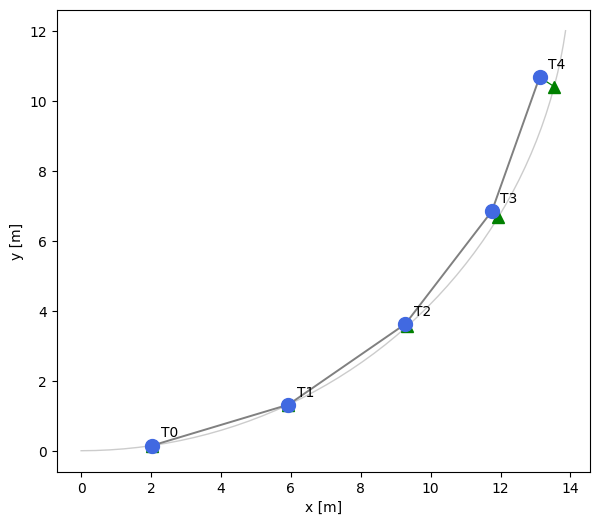

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# (optional) GT overlay
ax.plot(gt_frame_pos[:, 0], gt_frame_pos[:, 1], '-', color='0.8', lw=1.0, zorder=0)

# Variables
for k in range(K):
    ax.plot(*t[k, :2], 'o', color='royalblue', ms=10, zorder=3)
    ax.annotate(f'T{k}', t[k, :2], textcoords='offset points', xytext=(6, 6))

# Sequential BetweenFactorPose3 edges
for k in range(K - 1):
    ax.plot([t[k, 0], t[k+1, 0]], [t[k, 1], t[k+1, 1]],
            '-', color='grey', lw=1.4, zorder=1)

# Unary GPSFactor stubs
for k in gps_anchor_chunks:
    g = gps_pos[anchor_frame[k], :2]
    ax.plot(*g, '^', color='green', ms=8, zorder=2)
    ax.plot([t[k, 0], g[0]], [t[k, 1], g[1]],
            '-', color='green', lw=0.9, zorder=2)

ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

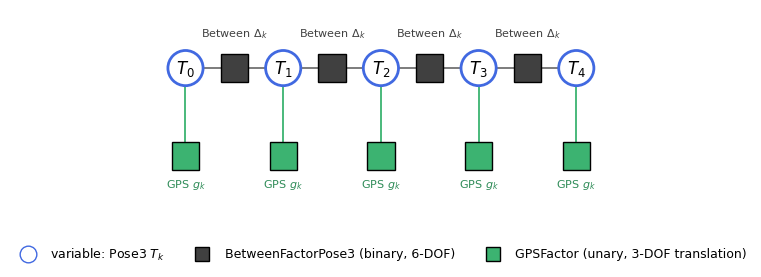

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

K = 5                          # n chunks
gps_anchor_every = 1           # which chunks carry a GPSFactor

fig, ax = plt.subplots(figsize=(10, 3.0))
ax.set_xlim(-0.8, K - 0.2)
ax.set_ylim(-1.4, 0.6)
ax.set_aspect('equal'); ax.axis('off')

var_y, between_y, gps_y = 0.0, 0.0, -0.9
r_var, s_fac = 0.18, 0.14      # circle radius, square half-side

# --- Variable nodes: T_0 ... T_{K-1} (open circles) ---
for k in range(K):
    ax.add_patch(Circle((k, var_y), r_var, facecolor='white',
                        edgecolor='royalblue', linewidth=2, zorder=3))
    ax.text(k, var_y, f'$T_{{{k}}}$', ha='center', va='center',
            fontsize=12, zorder=4)

# --- Between factors: binary, between T_k and T_{k+1} ---
for k in range(K - 1):
    fx, fy = k + 0.5, between_y
    ax.add_patch(Rectangle((fx - s_fac, fy - s_fac), 2*s_fac, 2*s_fac,
                           facecolor='0.25', edgecolor='black', zorder=3))
    # edges to the two variables it touches
    ax.plot([k,   fx - s_fac], [var_y, fy], '-', color='0.4', lw=1.2, zorder=1)
    ax.plot([k+1, fx + s_fac], [var_y, fy], '-', color='0.4', lw=1.2, zorder=1)
    ax.text(fx, fy + 0.32, r'$\mathrm{Between}\ \Delta_k$',
            ha='center', fontsize=8, color='0.25')

# --- GPS unary factors: one square per anchored chunk, hanging below ---
for k in range(0, K, gps_anchor_every):
    fx, fy = k, gps_y
    ax.add_patch(Rectangle((fx - s_fac, fy - s_fac), 2*s_fac, 2*s_fac,
                           facecolor='mediumseagreen', edgecolor='black', zorder=3))
    ax.plot([k, fx], [var_y - r_var, fy + s_fac], '-',
            color='mediumseagreen', lw=1.3, zorder=1)
    ax.text(fx, fy - 0.32, r'$\mathrm{GPS}\ g_k$',
            ha='center', fontsize=8, color='seagreen')

# --- Legend ---
legend = [
    Line2D([0], [0], marker='o', markerfacecolor='white', markeredgecolor='royalblue',
           markersize=12, lw=0, label=r'variable: Pose3 $T_k$'),
    Line2D([0], [0], marker='s', markerfacecolor='0.25', markeredgecolor='black',
           markersize=10, lw=0, label='BetweenFactorPose3 (binary, 6-DOF)'),
    Line2D([0], [0], marker='s', markerfacecolor='mediumseagreen', markeredgecolor='black',
           markersize=10, lw=0, label='GPSFactor (unary, 3-DOF translation)'),
]
ax.legend(handles=legend, loc='lower center', bbox_to_anchor=(0.5, -0.35),
          ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
